In [2]:
if (!require(igraph)) install.packages("igraph", dependencies = TRUE) # Libraries (Change the runtime type to R in Google Colab)
library(igraph)

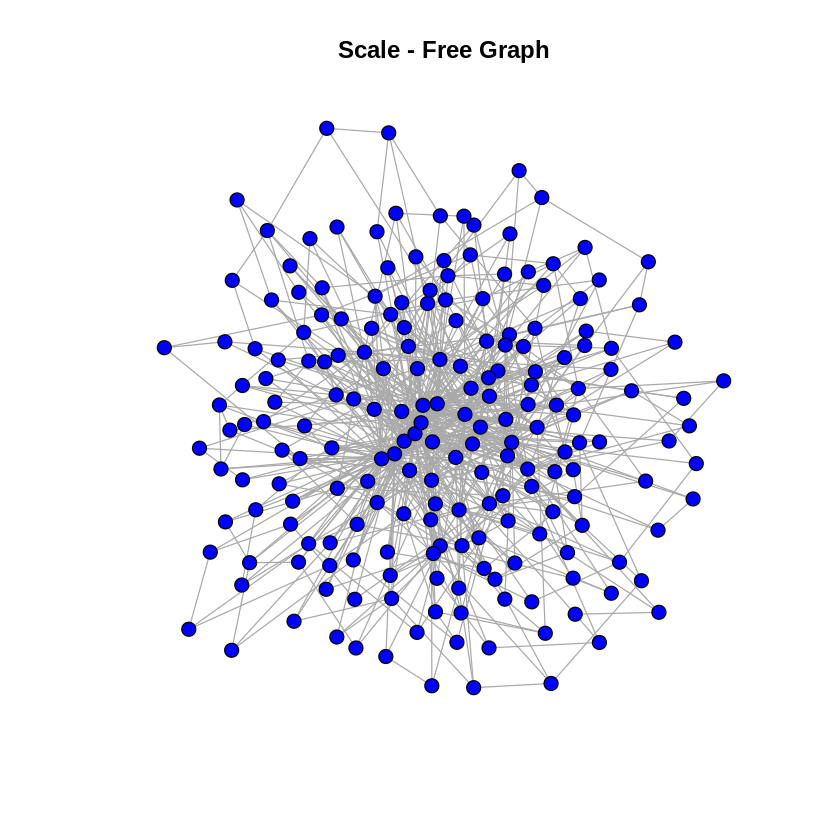

In [8]:
generate_power_law_degrees <- function(n, gamma, k_min) {
  probs <- (k_min:n)^(-gamma)
  probs <- probs / sum(probs)
  sample(k_min:n, n, replace = TRUE, prob = probs)
}

# Function for generating a scale-free graph
generate_scale_free_graph <- function(n, gamma, k_min) {
  repeat {
    degrees <- generate_power_law_degrees(n, gamma, k_min)
    if (sum(degrees) %% 2 == 0) break  # The sum of the powers must be even
  }
  g <- sample_degseq(degrees, method = "vl")
  return(g)
}

# Graph parameters
n <- 200      # Number of nodes
gamma <- 2.4
k_min <- 3   # Minimum node degree
g <- generate_scale_free_graph(n, gamma, k_min)

# Calculating node degrees
deg <- degree(g)

# Graph visualization
plot(g,
     layout = layout.fruchterman.reingold,
     vertex.size = 5,
     vertex.label = NA,
   vertex.color = "blue",
     edge.lty = 1, main = "Scale - Free Graph")

# Writing a graph to the edgelist file
write.table(as_edgelist(g), "N200_y2.4_small_hubs.edgelist", row.names = FALSE, col.names = FALSE)

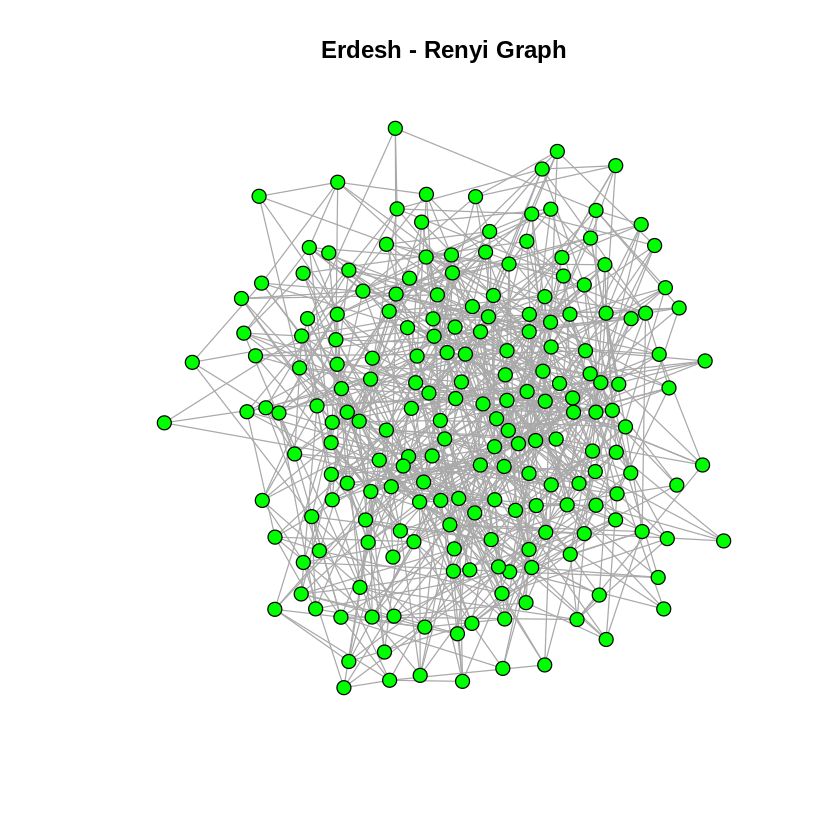

In [5]:
n <- 200     # number of nodes
p <- 0.04    # the probability of a connection between any two nodes

# Generation of the Erdős–Rényi graph
g <- erdos.renyi.game(n, p, type = "gnp", directed = FALSE)
plot(g, vertex.color = "green", vertex.size = 5, vertex.label = NA,
     main = "Erdesh - Renyi Graph")
write.table(as_edgelist(g), "N200_Erdesh_Renyi_Graph_0.04.edgelist", row.names = FALSE, col.names = FALSE)